# Codeabgabe für Data Visualization

> __<b><i>von Leon</i></b>__<br><br>
<b>Kurs:</b> WDS125<br>
<b>Datum:</b> 18.03.2026<br>
<b>Datensatz:</b> Airline Satisfaction

1. [Data Cleaning](#data_cleaning)
2. [Data Exploration](#data_exploration)
3. [Predictive Modelling](#predictive_modelling)

Bibliotheken importieren

In [47]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

os.makedirs("figures", exist_ok=True)

>### 1. Data Cleaning <a name="data_cleaning">

Datensatz einlesen

In [48]:
df = pd.read_csv("data/airline.csv", sep="|")
print(f"zeilen: {df.shape[0]} spalten: {df.shape[1]}")
df.head()

zeilen: 103907 spalten: 13


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Food and drink,On-board service,Leg room service,Departure Delay in Minutes,satisfaction,Customer ID,isPilot
0,Male,Loyal Customer,13.0,Personal Travel,Eco Plus,460,5,4,3,25,neutral or dissatisfied,0,False
1,Male,disloyal Customer,25.0,Business travel,Business,235,1,1,5,1,neutral or dissatisfied,1,False
2,Female,Loyal Customer,26.0,Business travel,Business,1142,5,4,3,0,satisfied,2,False
3,Female,Loyal Customer,25.0,Business travel,Business,562,2,2,-,11,neutral or dissatisfied,3,False
4,Male,Loyal Customer,61.0,Business travel,Business,214,4,3,4,0,satisfied,4,False


Überblick über die Daten

In [49]:
print("infos: ")
df.info()
print("describe: ")
df.describe()

infos: 
<class 'pandas.DataFrame'>
RangeIndex: 103907 entries, 0 to 103906
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      103907 non-null  str    
 1   Customer Type               103907 non-null  str    
 2   Age                         103904 non-null  float64
 3   Type of Travel              103907 non-null  str    
 4   Class                       103907 non-null  str    
 5   Flight Distance             103907 non-null  int64  
 6   Food and drink              103907 non-null  int64  
 7   On-board service            103907 non-null  int64  
 8   Leg room service            103907 non-null  str    
 9   Departure Delay in Minutes  103907 non-null  int64  
 10  satisfaction                103907 non-null  str    
 11  Customer ID                 103907 non-null  int64  
 12  isPilot                     103907 non-null  bool   
dtypes: bool(1), float

,Age,Flight Distance,Food and drink,On-board service,Departure Delay in Minutes,Customer ID
count,103904.000000,103907.000000,103907.000000,103907.00000,103907.000000,103907.000000
mean,39.381054,1189.437593,3.202123,3.38238,14.815191,51953.000000
std,15.121206,997.161287,1.329521,1.28834,38.230432,29995.511548
min,-24.000000,-200.000000,0.000000,0.00000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.00000,0.000000,25976.500000
50%,40.000000,843.000000,3.000000,4.00000,0.000000,51953.000000
75%,51.000000,1743.000000,4.000000,4.00000,12.000000,77929.500000
max,129.000000,4983.000000,5.000000,5.00000,1592.000000,103906.000000


Duplikate prüfen und entfernen

In [50]:
# auflisten wieviele gefunden werden
print("duplikate vorher:", df.duplicated().sum())
# eigendlich sinnlos da immer nur 0 gefunden wurden..
df = df.drop_duplicates()
print(f"neue shape: {df.shape}")

duplikate vorher: 0
neue shape: (103907, 13)


Ungültige Werte in Leg room service bereinigen

In [51]:
print("ungültige leg room service werte:", (pd.to_numeric(df["Leg room service"], errors="coerce").isna()).sum())
df["Leg room service"] = pd.to_numeric(df["Leg room service"], errors="coerce")

print("fehlende age-werte:", df["Age"].isna().sum())

df = df.dropna(subset=["Leg room service", "Age"])
df["Leg room service"] = df["Leg room service"].astype(int)
df["Age"] = df["Age"].astype(int)

ungültige leg room service werte: 2
fehlende age-werte: 3


Ausreißer mit Boxplots checken

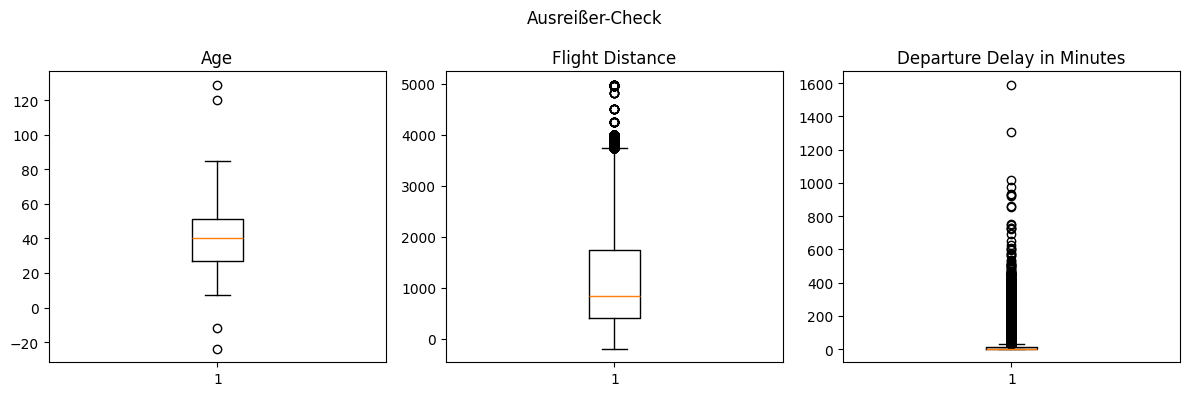

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["Age", "Flight Distance", "Departure Delay in Minutes"]):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.suptitle("Ausreißer-Check")
plt.tight_layout()
plt.savefig("figures/fig_outlier_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Unnötige Spalten entfernen

In [53]:
# unnötige felder löschen
df = df.drop(columns=["Customer ID", "isPilot"])
print(f"shape dannach: {df.shape}")
df.head()

shape dannach: (103902, 11)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Food and drink,On-board service,Leg room service,Departure Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,5,4,3,25,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,1,1,5,1,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,5,4,3,0,satisfied
4,Male,Loyal Customer,61,Business travel,Business,214,4,3,4,0,satisfied
5,Female,Loyal Customer,26,Personal Travel,Eco,1180,1,3,4,0,neutral or dissatisfied


***

>### 2. Data Exploration <a name="data_exploration">

Verteilung der Zielvariable

satisfaction
neutral or dissatisfied    58878
satisfied                  45024
Name: count, dtype: int64


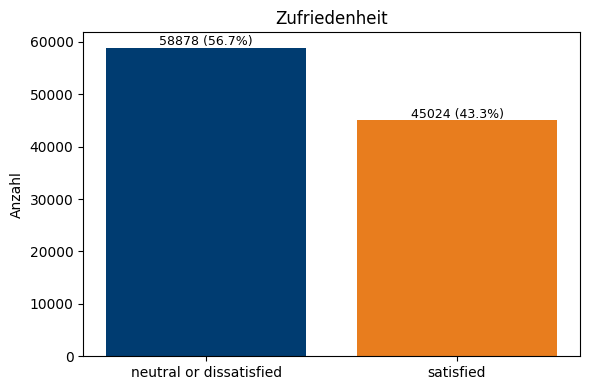

In [54]:
counts = df["satisfaction"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["#003c71", "#e87d1e"])
ax.set_title("Zufriedenheit")
ax.set_ylabel("Anzahl")

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 500,
            f"{h} ({h/len(df)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/fig_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Flugklassen anschauen

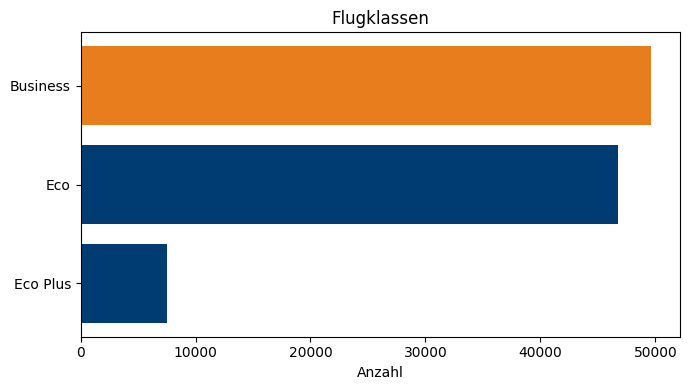

In [55]:
class_counts = df["Class"].value_counts().sort_values()
# hardcoded weil ich weiß grad nicht wie besser oder anders
remove_classes = ["Business Class", "Eco+", "Eco +", "Eco  +", "Business Klasse", "Economy"]

# wird hier überschrieben mit hardcoded zeug
class_counts = (
    df[~df["Class"].isin(remove_classes)]
    ["Class"].value_counts().sort_values()
)

farben = ["#e87d1e" if c == class_counts.idxmax() else "#003c71" for c in class_counts.index]
fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(class_counts.index, class_counts.values, color=farben)
ax.set_title("Flugklassen")
ax.set_xlabel("Anzahl")
plt.tight_layout()
plt.savefig("figures/fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


Altersverteilung als Histogramm

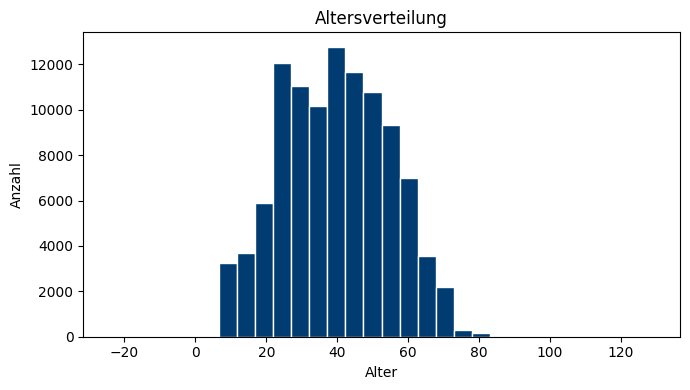

alterdurchschnitt: 39.4


In [56]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Age"], bins=30, color="#003c71", edgecolor="white")
ax.set_title("Altersverteilung")
ax.set_xlabel("Alter")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.savefig("figures/fig_age_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"alterdurchschnitt: {df['Age'].mean():.1f}")

Flugdistanz nach Zufriedenheit vergleichen

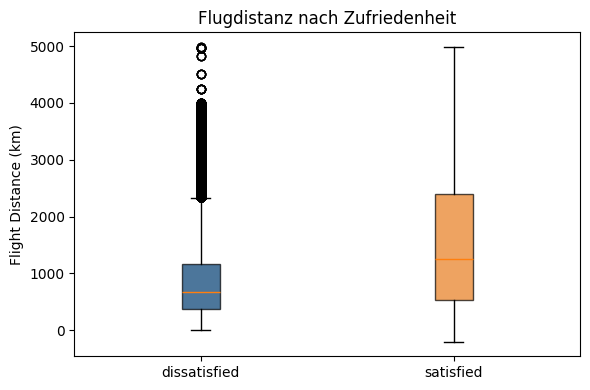

In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
data = [df[df["satisfaction"]=="neutral or dissatisfied"]["Flight Distance"], df[df["satisfaction"]=="satisfied"]["Flight Distance"]]
bp = ax.boxplot(data, tick_labels=["dissatisfied", "satisfied"], patch_artist=True)
bp["boxes"][0].set_facecolor("#003c71")
bp["boxes"][1].set_facecolor("#e87d1e")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_alpha(0.7)
ax.set_title("Flugdistanz nach Zufriedenheit")
ax.set_ylabel("Flight Distance (km)")
plt.tight_layout()
plt.savefig("figures/fig_distance_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Korrelationsmatrix der numerischen Spalten

spalten die zahlen haben: ['Age', 'Flight Distance', 'Food and drink', 'On-board service', 'Leg room service', 'Departure Delay in Minutes']


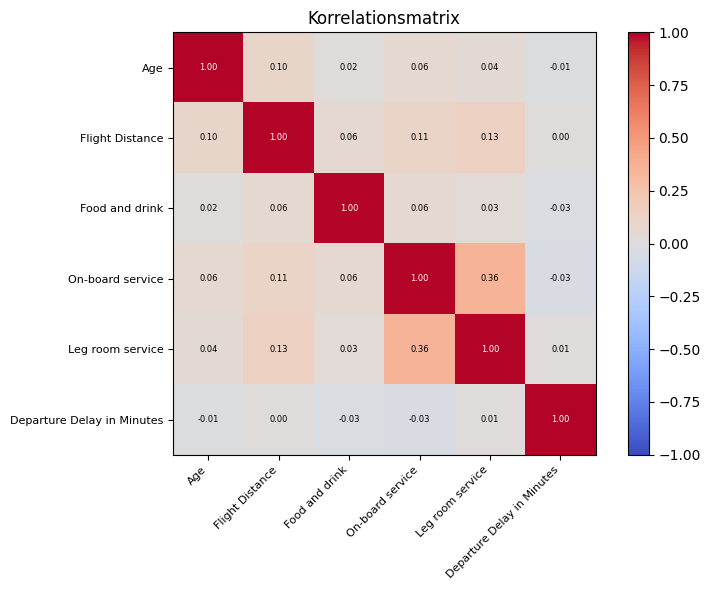

In [58]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("spalten die zahlen haben:", list(num_cols))
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(im)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
ax.set_title("Korrelationsmatrix")

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color="white" if abs(val) > 0.5 else "black")

plt.tight_layout()
plt.savefig("figures/fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Alter vs Flugdistanz als Scatterplot

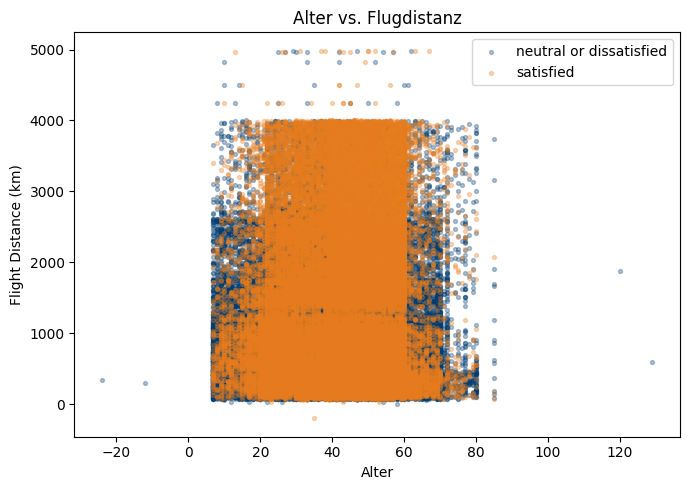

In [59]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [("neutral or dissatisfied", "#003c71"), ("satisfied", "#e87d1e")]:
    mask = df["satisfaction"] == label
    ax.scatter(df.loc[mask, "Age"], df.loc[mask, "Flight Distance"], c=color, alpha=0.3, s=8, label=label)
ax.set_title("Alter vs. Flugdistanz")
ax.set_xlabel("Alter")
ax.set_ylabel("Flight Distance (km)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

***

>### 3. Predictive Modelling <a name="predictive_modelling">

Kategorische (text) Spalten in Zahlen umwandeln

In [60]:
df_model = df.copy()

df_model["satisfaction"] = df_model["satisfaction"].map({"satisfied": 1, "neutral or dissatisfied": 0})

for col in df_model.select_dtypes(include="str").columns:
    df_model[col] = df_model[col].astype("category").cat.codes
    print(f"{col} kodiert")

df_model.head()

Gender kodiert
Customer Type kodiert
Type of Travel kodiert
Class kodiert


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Food and drink,On-board service,Leg room service,Departure Delay in Minutes,satisfaction
0,1,0,13,3,5,460,5,4,3,25,0
1,1,1,25,1,0,235,1,1,5,1,0
2,0,0,26,1,0,1142,5,4,3,0,1
4,1,0,61,1,0,214,4,3,4,0,1
5,0,0,26,3,3,1180,1,3,4,0,0


Daten aufteilen in Train, Val und Test

In [61]:
X = df_model.drop(columns=["satisfaction"])
y = df_model["satisfaction"]

X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)

print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Train: 83121
Val:   10390
Test:  10391


Random Forest trainieren

In [62]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Vorhersage auf Testdaten

In [63]:
y_pred = clf.predict(X_test)
print(f"vorhersage: \n\r{classification_report(y_test, y_pred)}")

vorhersage: 
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      5888
           1       0.88      0.79      0.83      4503

    accuracy                           0.86     10391
   macro avg       0.87      0.86      0.86     10391
weighted avg       0.86      0.86      0.86     10391



Confusion Matrix plotten

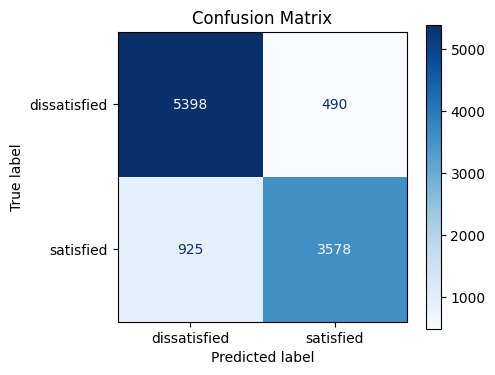

Fertig!


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["dissatisfied", "satisfied"], cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("figures/fig_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()